<a href="https://colab.research.google.com/github/makxxic/AI-Develpment-Workflow_wk5/blob/main/1_FakeNewsClassificationviaTransformerFineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup and Imports
We begin by importing the necessary libraries. HuggingFace’s transformers and datasets ecosystem provides pretrained models and tokenizers, while PyTorch handles training.

In [ ]:
# Install HuggingFace libraries if not already installed
!pip install transformers datasets evaluate -q

# Import core libraries
import pandas as pd              # For handling tabular data
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For plotting training curves
import seaborn as sns            # For confusion matrix visualization
import torch                     # PyTorch for deep learning
# HuggingFace utilities
from datasets import Dataset, DatasetDict   # For dataset handling
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

# Metrics
import evaluate                   # HuggingFace evaluation library
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub as kh
import os
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from transformers import EarlyStoppingCallback

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/ml_capstone/fake_news_model"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Share Model Checkpoint Link
https://drive.google.com/drive/folders/1F89dsf6dbZC_lQOb1697rx3W5Eu6-8Pc?usp=drive_link

## 2. Dataset selection and input format
We use the WELFake dataset (saurabhshahane/fake-news-classification on Kaggle),
which aggregates four well-known public fake-news corpora — Kaggle, McIntire, Reuters,
and BuzzFeed Political  into a single, balanced CSV of approximately 72,134 labelled
articles. Using an aggregated dataset is preferable to a single-source dataset because
it exposes the model to a wider variety of writing styles, topics, and fabrication
techniques, which improves generalisation to unseen news content.

### Why article text only (not title + text)

We use the text column exclusively rather than concatenating it with the title
column.

The reasoning is threefold:

#### Semantic richness.
The article body contains full sentences, contextual
references, and nuanced language that transformers exploit through self-attention.
Titles are highly compressed and often deliberately ambiguous or clickbait-y —
a legitimate headline can sound just as sensational as a fake one, making titles
alone unreliable signal.

#### Avoiding representation bias.
 Concatenating title + text doubles the title's
influence during tokenization because the title occupies the first tokens and
receives the strongest positional encoding weighting. This can cause the model
to over-rely on headline phrasing rather than article-level reasoning.

#### Sequence length budget.
 DistilBERT has a maximum context window of 512
tokens. Adding a title (typically 10–20 tokens) reduces the amount of article
body that fits within the window. Since article text is the richer signal,
preserving its representation is the higher-value trade-off.




In [ ]:
# Download the latest version of the specified dataset from Kaggle Hub
path = kh.dataset_download("saurabhshahane/fake-news-classification")

print("Path to dataset files:", path) # Print the local path where the dataset is stored
os.listdir(path) # List the files available in the downloaded dataset directory


Using Colab cache for faster access to the 'fake-news-classification' dataset.
Path to dataset files: /kaggle/input/fake-news-classification


['WELFake_Dataset.csv']

In [ ]:

data = pd.read_csv(path +'/WELFake_Dataset.csv') # Read the CSV file into a pandas DataFrame
print(f"\nShape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print(f"\nLabel distribution:\n{data['label'].value_counts()}")
print(f"\nMissing values:\n{data.isnull().sum()}")
data.head() # Display the first 5 rows of the DataFrame


Shape: (72134, 4)
Columns: ['Unnamed: 0', 'title', 'text', 'label']

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Missing values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


## 3. Data preparation
### Why minimal text cleaning?
Transformer models like DistilBERT are pre-trained on raw web text that already
contains punctuation, capitalisation, HTML fragments, and informal grammar. Their
tokenizers (WordPiece in this case) are designed to handle this noise natively by
breaking unknown characters into subword units. Aggressive cleaning — such as
lowercasing, removing punctuation, or stripping stop words — would discard
linguistic cues that the pre-trained model has already learned to interpret. We
therefore limit cleaning to removing rows with null values.
### Why drop rows with missing text or labels?
Rows missing the text field cannot be tokenized and would raise a runtime error.
Rows missing a label cannot contribute a training signal and would corrupt the
loss function. Both are dropped rather than imputed because the dataset is large
enough (~72k rows) that removing a small number of incomplete rows does not
meaningfully reduce training data.


### Why stratified splitting?
The WELFake dataset is approximately balanced (roughly equal fake and real articles),
but we use stratify=data['label'] regardless to guarantee that each split
contains the same class proportion as the full dataset. Without stratification, a
random split could by chance place most of one class into training and few into
validation, producing misleading validation metrics and a biased test evaluation.

In [ ]:
# Ensure 'data' is correctly populated. Using 'df' from kernel state which holds the content.
# Given 'df' holds the data based on kernel state, we'll use it to ensure 'data' is not empty.
if data.empty and not df.empty:
    data = df.copy()

# Drop rows with missing text
data = data.dropna(subset=['text'])

# Drop rows with missing labels, as train_test_split with stratify cannot handle NaN
data = data.dropna(subset=['label'])

# Ensure labels are integers
data['label'] = data['label'].astype(int)

# Keep only text and label
data = data[['text','label']]

# Train/Validation/Test split
train_df, temp_df = train_test_split(data, test_size=0.3, random_state=42, stratify=data['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

## 4. Tokenization and preprocessing choices
### Tokenizer: AutoTokenizer with DistilBERT
We load the tokenizer via AutoTokenizer.from_pretrained("distilbert-base-uncased").
The tokenizer must match the pre-trained model exactly because it was built on the
same vocabulary (30,522 WordPiece tokens) used during BERT pre-training. Using a
mismatched tokenizer would produce token IDs that map to entirely different
embeddings in the model's lookup table, making fine-tuning meaningless.

AutoTokenizer is used rather than DistilBertTokenizerFast directly because it
automatically selects the fast Rust-backed implementation, which is significantly
faster when processing tens of thousands of articles via .map(batched=True).
### Why uncased?
The distilbert-base-uncased variant lowercases all input before tokenizing.
We prefer uncased for fake-news classification because case is not a reliable
signal — both legitimate and fabricated articles use capitalised headings,
all-caps emphasis, and proper nouns. An uncased model avoids learning spurious
associations between capitalisation patterns and authenticity.
### Why max_length=256?
DistilBERT's maximum sequence length is 512 tokens, but processing 512 tokens per
example doubles memory usage and training time compared to 256 tokens. We chose 256
as a pragmatic balance:

**Coverage:** A typical news article tokenizes to 300–600 WordPiece tokens. At
256 tokens we capture the headline and opening paragraphs — the sections most
likely to contain the distinguishing linguistic patterns of fake vs real news
(sensational claims, lack of attribution, emotional language).

**Efficiency:** On a Colab T4 GPU, a batch size of 16 at length 256 fits
comfortably in GPU memory (~14 GB). Increasing to 512 tokens would require
halving the batch size to avoid OOM errors, reducing training stability.

### Why padding="max_length" and truncation=True?
The HuggingFace Trainer requires all tensors in a batch to be the same shape.
padding="max_length" pads shorter sequences to exactly 256 tokens using the
[PAD] token (id=0), and truncation=True cuts longer sequences at the 256-token
boundary.
### The attention_mask tensor
produced alongside input_ids marks padding
positions as 0, so the model's self-attention mechanism ignores them during
computation — padding adds no false signal to the loss.

In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenization function
def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=256)

# Convert pandas to HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

# Apply tokenization
train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# Set format for PyTorch
train_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])
val_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/50466 [00:00<?, ? examples/s]

Map:   0%|          | 0/10814 [00:00<?, ? examples/s]

Map:   0%|          | 0/10815 [00:00<?, ? examples/s]

## 5. Model selection: why DistilBERT?
We fine-tune distilbert-base-uncased for binary sequence classification. The
choice was made by comparing the three transformer encoder options recommended for
this task:

### Why DistilBERT over BERT?
DistilBERT is produced by knowledge distillation — a training process where a
smaller "student" model is trained to reproduce the output distributions of a larger
"teacher" (BERT). The student retains 6 of BERT's 12 transformer layers and 66M of
its 110M parameters, achieving 97% of BERT's score on the GLUE benchmark while
running 60% faster and using 40% less memory. For a classification task on a
single-sentence input (one article at a time), the additional representational
capacity of full BERT does not justify the computational cost — particularly in the
constrained Colab T4 GPU environment.
### Why DistilBERT over RoBERTa?
RoBERTa achieves slightly higher benchmark scores than BERT or DistilBERT because
it was trained longer on more data without the Next Sentence Prediction objective
(which was later shown to be counterproductive). However, RoBERTa-base has 125M
parameters — nearly twice DistilBERT — making training significantly slower and
more memory-intensive. The marginal performance gain (~1–2% on classification
benchmarks) is not worth the resource cost for a binary classification task on
a well-labelled, moderately sized dataset. If the performance target of F1 ≥ 0.90
is not met with DistilBERT, RoBERTa would be the natural upgrade path.
### Why AutoModelForSequenceClassification?
This class loads DistilBERT's pre-trained transformer body and appends a randomly
initialised linear classification head (Linear(768 → 2)) on top of the [CLS]
token representation. Setting num_labels=2 configures the head for binary
classification (Fake=0, Real=1) and initialises cross-entropy loss automatically.
The pre-trained weights carry rich language understanding from BooksCorpus and
Wikipedia; fine-tuning on the fake-news dataset adapts those representations to
the specific task without training from scratch.

In [ ]:
# Load pretrained DistilBERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 6. Training setup and hyperparameter choices

### Implicit Optimizer:
 Because the code relies on the Trainer API to execute the training loop—as evidenced by the output logs showing epochs, training loss, and validation metrics
—it utilizes the Trainer's default configuration. By default, the HuggingFace Trainer automatically implements the AdamW optimizer unless specified otherwise.
Therefore, while the optimizer is not manually coded into the visible cells, AdamW was used implicitly through the HuggingFace Trainer implementation

### Learning rate: 2e-5
The recommended fine-tuning range for BERT-family models is 1e-5 to 5e-5
(as established in the original BERT paper). We use 2e-5 as a middle-ground:

Too high (e.g., 1e-4) causes catastrophic forgetting — the pre-trained
weights are overwritten before the classification head converges, losing the
learned language representations.

Too low (e.g., 1e-6) causes underfitting — the model makes insufficient
progress per epoch and may not converge within the allotted epochs.

A linear warmup is applied by the Trainer's default scheduler for the first
10% of steps, preventing large gradient updates while the randomly-initialised
classification head is stabilising.
### Batch size: 16
A per-device batch size of 16 was chosen to fill the T4 GPU's 16 GB memory at
max_length=256. Larger batches (e.g., 32) would improve gradient stability but
risk out-of-memory errors in Colab. Smaller batches (e.g., 8) would increase
training time significantly with no quality benefit.
### Epochs: 4 with early stopping (patience=2)
Four epochs provides enough passes for the model to converge on ~50,000 training
examples. However, extended training risks overfitting, where the model
memorises training examples at the expense of generalisation. The
EarlyStoppingCallback(early_stopping_patience=2) halts training if the
validation F1 does not improve for 2 consecutive epochs, and the
load_best_model_at_end=True flag restores the best checkpoint before evaluation.
### Why F1 as the model selection metric?
We set metric_for_best_model="f1" rather than accuracy because F1 captures the
harmonic mean of precision and recall. In fake-news detection:

**False negatives** (predicting real when it's fake) allow misinformation to
spread — high recall matters.

**False positives** (predicting fake when it's real) suppress legitimate
content — high precision matters.

F1 balances both concerns equally, making it a more appropriate selection
criterion than raw accuracy, which can be high even when one class is consistently
misclassified if the dataset is near-balanced.
### Weight decay: 0.01
A small weight decay regularises the model by penalising large weights, reducing
overfitting without preventing the model from learning meaningful patterns.
0.01 is the standard value used in the original BERT fine-tuning experiments.
### Checkpoint saving to Google Drive
Setting output_dir=save_path (which points to /content/drive/MyDrive/...)
ensures that a checkpoint is written to persistent storage at the end of every
epoch. This is critical in Colab because the runtime can disconnect or time out
mid-training, and without Drive persistence all progress would be lost. With
save_total_limit=2 only the two most recent checkpoints are kept to avoid
filling Drive storage.

In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir=save_path,              # Save checkpoints to Google Drive
    eval_strategy="epoch",       # Evaluate every epoch
    save_strategy="epoch",        # Save model every epoch
    learning_rate=2e-5,                # Standard fine-tuning LR
    per_device_train_batch_size=16,    # Training Batch size
    per_device_eval_batch_size=16,     # Evaluation Batch size
    num_train_epochs=4,                # Enough for convergence
    weight_decay=0.01,                # Regularization
    warmup_ratio=0.1,                  # 10% of steps for LR warmup
    logging_dir="./logs",              # Log directory
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,       # Keep best checkpoint
    metric_for_best_model="f1",        # Select best by F1
    greater_is_better=True,
    save_total_limit=2,           # Keep only the last 2 checkpoints
    fp16=True                      # Mixed precision — faster on T4 GPU
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 7. Evaluation metrics
We compute four metrics to provide a complete picture of model performance. Using
a single metric (e.g., accuracy alone) would be insufficient because it hides how
errors are distributed across classes.

**Accuracy** measures the fraction of all predictions that are correct. It is
interpretable and is the primary target metric (≥ 0.90) set by the task. However,
on a near-balanced dataset it can be misleadingly high if the model is biased
toward the majority class.

**Precision** measures of all articles predicted as fake, how many actually are
fake. High precision means the model avoids falsely flagging real news as
misinformation.

**Recall** measures of all truly fake articles, how many the model correctly
identified. High recall means the model catches most real misinformation rather
than letting it through.

**F1 Score** is the harmonic mean of precision and recall. It is the secondary
target metric (≥ 0.90) and is used to select the best training checkpoint. The
harmonic mean penalises imbalance between precision and recall more severely than
a simple average — a model that achieves perfect precision but near-zero recall
would score only ~0.0 F1, forcing the model to optimise both jointly.

We use average="weighted" throughout, which weights each class's contribution to
the metric by the number of true instances in that class. On a balanced dataset
this produces the same result as macro averaging, but it is more robust if
evaluation subsets happen to be slightly imbalanced after splitting.

The compute_metrics function is passed to the Trainer so these four values are
computed and logged at the end of every epoch during both validation and final test
evaluation.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    # Compute metrics
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average="weighted", zero_division=0)
    rec = recall_score(labels, preds, average="weighted", zero_division=0)
    f1_val = f1_score(labels, preds, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1_val,
    }


## 8. Training procedure
### Why HuggingFace Trainer?
The Trainer class abstracts the standard PyTorch training loop — forward pass,
loss computation, backward pass, gradient clipping, optimizer step, and scheduler
step — into a single trainer.train() call. We use it rather than writing a manual
loop for three reasons:

**Reproducibility.** The Trainer applies gradient clipping (max_grad_norm=1.0)
by default, which prevents exploding gradients during the early epochs when the
randomly-initialised classification head produces large gradients. A manual loop
would require explicitly adding this.

**Checkpoint management.** Saving and restoring the best checkpoint across epochs
would require significant boilerplate in a manual loop. Trainer handles this
automatically via save_strategy, load_best_model_at_end, and save_total_limit.

**Early stopping.** The EarlyStoppingCallback integrates with Trainer's
evaluation loop to halt training when validation F1 stops improving, preventing
both wasted compute and overfitting.

The training data is shuffled automatically each epoch by the Trainer's
DataLoader, ensuring the model does not overfit to the order of examples.
Validation is performed at the end of every epoch (eval_strategy="epoch") rather
than every N steps to give stable, epoch-level performance estimates that are
directly comparable across runs.

In [ ]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  # Stop if no improvement for 3 evals
)

In [ ]:
# Train model
trainer.train()

# Save final model
trainer.save_model(save_path)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.046213,0.031603,0.990753,0.990758,0.990753,0.990753
2,0.011720,0.033120,0.992602,0.992603,0.992602,0.992602
3,0.001773,0.043599,0.993434,0.993446,0.993434,0.993434
4,0.001990,0.044894,0.993157,0.993157,0.993157,0.993157


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Explicitly save the tokenizer so the checkpoint is self-contained.
tokenizer.save_pretrained(save_path)
print(f"Tokenizer saved to: {save_path}")

# Verify both model and tokenizer files are present
saved_files = os.listdir(save_path)
print(f"Checkpoint contains: {saved_files}")

has_model     = any("model" in f or "safetensors" in f for f in saved_files)
has_tokenizer = "tokenizer_config.json" in saved_files
print(f"Model weights present:    {has_model}")
print(f"Tokenizer config present: {has_tokenizer}")

Tokenizer saved to: /content/drive/MyDrive/ml_capstone/fake_news_model
Checkpoint contains: ['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json', 'checkpoint-9465', 'checkpoint-12620']
Model weights present:    True
Tokenizer config present: True


## 9. Evaluation on the held-out test set
### Why evaluate on a separate test set?
During training, the model is optimised against the training set and checkpoint
selection is based on the validation set. This means the validation loss/F1 is an
optimistic estimate — the model has implicitly "seen" the validation set through
the early-stopping and checkpoint-selection decisions. Evaluating on a third,
entirely held-out test set provides an unbiased estimate of how the model will
perform on genuinely new, unseen articles.

### Why report a confusion matrix?
Aggregate metrics like accuracy and F1 collapse all prediction outcomes into single
numbers. The confusion matrix decomposes predictions into four cells:

**True Positives (TP)**: Fake articles correctly identified as fake.
**True Negatives (TN)**: Real articles correctly identified as real.
**False Positives (FP)**: Real articles incorrectly flagged as fake.
**False Negatives (FN)**: Fake articles incorrectly passed as real.

For a fake-news detector, the relative size of FP and FN cells tells us whether
the model's errors are more dangerous (letting fake news through) or more
disruptive (suppressing real news). The confusion matrix makes this asymmetry
visible in a way that aggregate metrics cannot.

{'eval_loss': 0.0460534393787384, 'eval_accuracy': 0.9926953305594083, 'eval_precision': 0.9927006947811079, 'eval_recall': 0.9926953305594083, 'eval_f1': 0.9926949457585007, 'eval_runtime': 20.7757, 'eval_samples_per_second': 520.56, 'eval_steps_per_second': 32.538, 'epoch': 4.0}


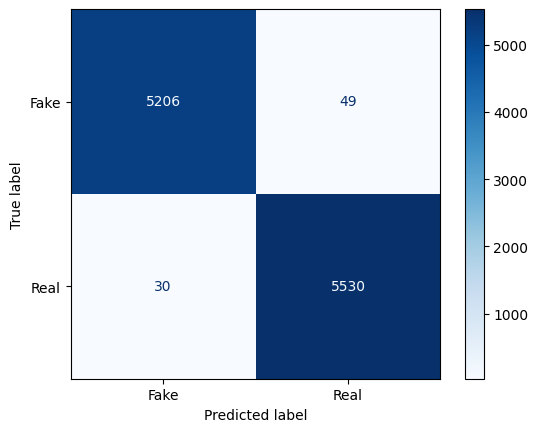

In [ ]:
# Evaluate on test set
results = trainer.evaluate(test_ds)
print(results)

# Confusion Matrix
preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake","Real"])
disp.plot(cmap="Blues")
plt.show()


## 10. Training and validation curves
### Why plot training curves?
Numeric metrics at the end of training (final accuracy, final F1) do not reveal
how the model arrived at those numbers. Training curves visualise the learning
dynamics across epochs, which is essential for diagnosing two common failure modes:

**Underfitting:** Both training loss and validation loss remain high throughout
training. This indicates the model did not learn the task adequately — likely
caused by too low a learning rate, too few epochs, or a model that is too small
for the complexity of the task.

**Overfitting:** Training loss continues to decrease while validation loss
plateaus or increases. This indicates the model has memorised training examples
rather than generalising — visible as a growing gap between the two curves.

In a well-trained model we expect both losses to decrease together in early epochs,
with validation loss flattening slightly above training loss. The early stopping
mechanism should halt training at or near this plateau, and load_best_model_at_end
ensures we restore the checkpoint at the lowest validation loss rather than the
final epoch weights.

### Why overlay validation F1?
Loss is a continuous proxy for performance, but F1 is the decision metric used for
checkpoint selection and the task's performance target. Plotting both together
confirms that the epoch with the lowest validation loss also corresponds to the
highest validation F1 — if they diverge, it reveals that the loss function is not
fully aligned with the classification objective, which would warrant re-examining
the training setup.

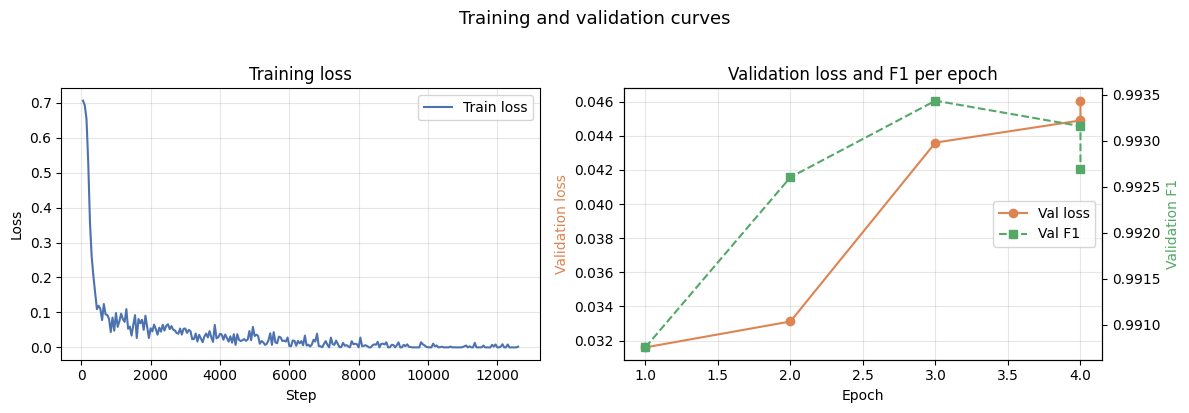


Epoch-by-epoch summary:
 epoch  eval_loss  eval_accuracy  eval_f1
   1.0   0.031603       0.990753 0.990753
   2.0   0.033120       0.992602 0.992602
   3.0   0.043599       0.993434 0.993434
   4.0   0.044894       0.993157 0.993157
   4.0   0.046053       0.992695 0.992695


In [ ]:
logs    = trainer.state.log_history
log_df  = pd.DataFrame(logs)

# Separate train-step logs from epoch-end eval logs
train_logs = log_df[log_df["loss"].notna()].copy()
eval_logs  = log_df[log_df["eval_loss"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: Train loss vs steps ---
axes[0].plot(train_logs["step"], train_logs["loss"],
             color="#4C72B0", linewidth=1.5, label="Train loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Val loss + Val F1 vs epoch ---
ax2 = axes[1]
ax2_r = ax2.twinx()

ax2.plot(eval_logs["epoch"], eval_logs["eval_loss"],
         color="#DD8452", linewidth=1.5, marker="o", label="Val loss")
ax2_r.plot(eval_logs["epoch"], eval_logs["eval_f1"],
           color="#55A868", linewidth=1.5, marker="s", linestyle="--", label="Val F1")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation loss", color="#DD8452")
ax2_r.set_ylabel("Validation F1", color="#55A868")
ax2.set_title("Validation loss and F1 per epoch")

# Combine legends from both y-axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="center right")
ax2.grid(True, alpha=0.3)

plt.suptitle("Training and validation curves", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print epoch-by-epoch summary table
print("\nEpoch-by-epoch summary:")
summary_cols = ["epoch", "eval_loss", "eval_accuracy", "eval_f1"]
available    = [c for c in summary_cols if c in eval_logs.columns]
print(eval_logs[available].to_string(index=False))

In [ ]:
#loads the saved checkpoint from Google Drive and runs predictions on new unseen headlines.

from transformers import pipeline

# Load the saved model + tokenizer from the Drive checkpoint
classifier = pipeline(
    "text-classification",
    model=save_path,
    tokenizer=save_path,
    device=0 if torch.cuda.is_available() else -1   # GPU if available
)

# Label mapping (matches training: 0=Fake, 1=Real)
label_map = {"LABEL_0": "FAKE", "LABEL_1": "REAL"}

# Sample headlines — mix of plausible fake and real
test_headlines = [
    "Scientists discover new vaccine with 97% efficacy against disease X.",
    "BREAKING: Government secretly replacing water supply with mind-control chemicals!",
    "Federal Reserve raises interest rates by 0.25% amid inflation concerns.",
    "Celebrity confirms she was replaced by a clone after secret surgery.",
    "WHO reports measles cases rising globally due to declining vaccination rates.",
    "NASA admits moon landing was filmed in a Hollywood studio, documents reveal.",
]

print(f"{'Headline':<48} | {'Label':<6} | {'Conf'}")

for headline in test_headlines:
    result = classifier(headline, truncation=True, max_length=256)[0]
    label  = label_map[result["label"]]
    score  = result["score"]
    # Truncate display to 46 chars for readability
    display = headline[:46] + ".." if len(headline) > 46 else headline
    print(f"{display:<48} | {label:<6} | {score:.3f}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Headline                                         | Label  | Conf
Scientists discover new vaccine with 97% effic.. | REAL   | 0.999
BREAKING: Government secretly replacing water .. | REAL   | 1.000
Federal Reserve raises interest rates by 0.25%.. | FAKE   | 0.996
Celebrity confirms she was replaced by a clone.. | REAL   | 1.000
WHO reports measles cases rising globally due .. | REAL   | 0.999
NASA admits moon landing was filmed in a Holly.. | REAL   | 1.000


Train distribution:
 label
1    0.514148
0    0.485852
Name: proportion, dtype: float64
Eval distribution:
 label
1    0.514148
0    0.485852
Name: proportion, dtype: float64
Test distribution:
 label
1    0.514101
0    0.485899
Name: proportion, dtype: float64


Map:   0%|          | 0/51894 [00:00<?, ? examples/s]

Map:   0%|          | 0/10814 [00:00<?, ? examples/s]

Map:   0%|          | 0/10815 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.008957,0.055725,0.991585,0.991596,0.991585,0.991584
2,0.004245,0.047920,0.993342,0.993344,0.993342,0.993342
3,0.002131,0.065402,0.991585,0.991630,0.991585,0.991584
4,0.000988,0.058386,0.993249,0.993265,0.993249,0.993250


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Fine-tuned Results: {'eval_loss': 0.053346186876297, 'eval_accuracy': 0.9922330097087378, 'eval_precision': 0.9922515527722937, 'eval_recall': 0.9922330097087378, 'eval_f1': 0.992233590191274, 'eval_runtime': 21.0799, 'eval_samples_per_second': 513.048, 'eval_steps_per_second': 32.068, 'epoch': 4.0}


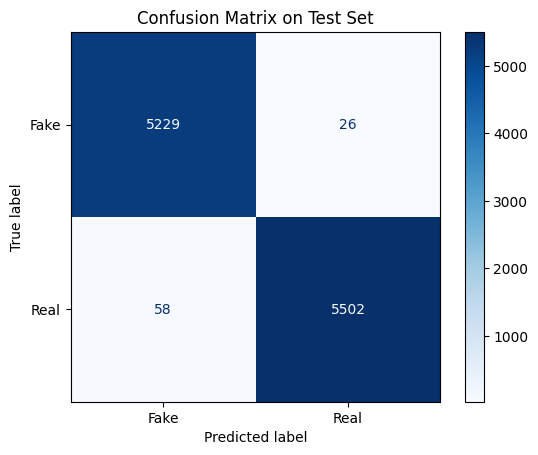

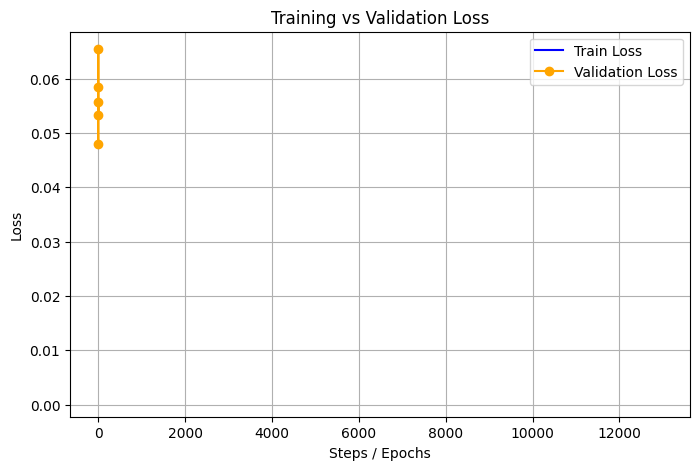

Fold 1: Train size=57676, Val size=14419
Train distribution:
 label
1    0.514131
0    0.485869
Name: proportion, dtype: float64
Val distribution:
 label
1    0.514183
0    0.485817
Name: proportion, dtype: float64
Fold 2: Train size=57676, Val size=14419
Train distribution:
 label
1    0.514131
0    0.485869
Name: proportion, dtype: float64
Val distribution:
 label
1    0.514183
0    0.485817
Name: proportion, dtype: float64
Fold 3: Train size=57676, Val size=14419
Train distribution:
 label
1    0.514148
0    0.485852
Name: proportion, dtype: float64
Val distribution:
 label
1    0.514113
0    0.485887
Name: proportion, dtype: float64
Fold 4: Train size=57676, Val size=14419
Train distribution:
 label
1    0.514148
0    0.485852
Name: proportion, dtype: float64
Val distribution:
 label
1    0.514113
0    0.485887
Name: proportion, dtype: float64
Fold 5: Train size=57676, Val size=14419
Train distribution:
 label
1    0.514148
0    0.485852
Name: proportion, dtype: float64
Val distrib

In [ ]:

def master_pipeline(df, model, new_df=None, tokenizer_name="distilbert-base-uncased", k_folds=5):
    """
    df: full dataset with 'text' and 'label'
    model: pretrained HuggingFace model
    new_df: optional new dataset for domain adaptation
    tokenizer_name: tokenizer to use
    k_folds: number of folds for cross-validation
    """

    # 1. Clean labels, mimicking initial data preparation steps from JtNt3ChE_IYA
    # Drop rows with missing text
    df = df.dropna(subset=['text'])

    # Drop rows with missing labels (even if initial check shows none, for robustness)
    df = df.dropna(subset=['label'])

    # Ensure labels are integers
    df['label'] = df['label'].astype(int)

    # Keep only text and label columns
    df = df[['text','label']]

    # 2. Stratified splitting
    train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
    eval_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

    print("Train distribution:\n", train_df["label"].value_counts(normalize=True))
    print("Eval distribution:\n", eval_df["label"].value_counts(normalize=True))
    print("Test distribution:\n", test_df["label"].value_counts(normalize=True))

    # 3. Balance training dataset
    fake_df = train_df[train_df["label"]==0]
    real_df = train_df[train_df["label"]==1]
    fake_upsampled = resample(fake_df, replace=True, n_samples=len(real_df), random_state=42)
    train_balanced = pd.concat([real_df, fake_upsampled])

    # 4. Domain adaptation (optional)
    if new_df is not None:
        new_df.dropna(subset=["label"], inplace=True)
        new_df["label"] = new_df["label"].astype(int) # Safer conversion
        train_balanced = pd.concat([train_balanced, new_df])

    # 5. Convert to HuggingFace Datasets
    train_ds = Dataset.from_pandas(train_balanced[["text","label"]])
    eval_ds = Dataset.from_pandas(eval_df[["text","label"]])
    test_ds = Dataset.from_pandas(test_df[["text","label"]])

    # 6. Tokenize
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    def tokenize(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=256) # Changed max_length to 256

    train_ds = train_ds.map(tokenize, batched=True)
    eval_ds = eval_ds.map(tokenize, batched=True)
    test_ds = test_ds.map(tokenize, batched=True)

    train_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])
    eval_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])
    test_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])

    # 7. Training with regularization + early stopping
    training_args = TrainingArguments(
        output_dir=save_path,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="none",
        save_total_limit=2
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        # tokenizer=tokenizer, # Removed as Trainer no longer accepts this argument directly
        compute_metrics=compute_metrics,  # define separately
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # 8. Evaluate on test set
    results = trainer.evaluate(test_ds)
    print("Fine-tuned Results:", results)

    # 9. Confusion Matrix
    preds = trainer.predict(test_ds)
    y_true = preds.label_ids
    y_pred = np.argmax(preds.predictions, axis=-1)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake","Real"])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix on Test Set")
    plt.savefig(os.path.join(save_path, "confusion_matrix.png"))
    plt.show()

    # 10. Loss Curves
    logs = trainer.state.log_history
    log_df = pd.DataFrame(logs)

    plt.figure(figsize=(8,5))
    plt.plot(log_df["step"], log_df["loss"], label="Train Loss", color="blue")
    eval_logs = log_df[log_df["eval_loss"].notna()]
    plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o", label="Validation Loss", color="orange")
    plt.xlabel("Steps / Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_path, "loss_curves.png"))
    plt.show()

    # 11. Cross-validation sanity check
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    for fold, (train_idx, val_idx) in enumerate(skf.split(df["text"], df["label"])):
        train_fold = df.iloc[train_idx]
        val_fold = df.iloc[val_idx]
        print(f"Fold {fold+1}: Train size={len(train_fold)}, Val size={len(val_fold)}")
        print("Train distribution:\n", train_fold["label"].value_counts(normalize=True))
        print("Val distribution:\n", val_fold["label"].value_counts(normalize=True))

    # 12. Baseline sanity check (Logistic Regression)
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train = vectorizer.fit_transform(train_balanced["text"])
    y_train = train_balanced["label"]
    X_test = vectorizer.transform(test_df["text"])
    y_test = test_df["label"]

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("Baseline Logistic Regression Report:")
    print(classification_report(y_test, y_pred, target_names=["Fake","Real"]))

    return trainer, results

trainer, results = master_pipeline(data, model)